# VarDyn-QG WHIRLS run
This notebook runs the VarDyn-QG configuration for the WHIRLS Agulhas experiment, from setup through assimilation and diagnostics.


Select the GPU device that JAX/CUDA should use for this notebook session.


In [1]:
import os 
NUM_GPU = '0'
os.environ['CUDA_VISIBLE_DEVICES'] = NUM_GPU

Point the notebook to the WHIRLS VarDyn-QG configuration file.


In [2]:
path_config = 'config_VarDyn-QG.py'

Add the local VarDyn mapping package to sys.path so the src modules can be imported from the notebook.


In [3]:
import sys
sys.path.append('/home/flo/VarDyn/mapping')

Load and merge the experiment configuration with the VarDyn defaults.


In [4]:
from src import exp
config = exp.Exp(path_config)

name_experiment: VarDyn-QG
name_exp_save: VarDyn-QG
path_save: ./outputs/VarDyn-QG
tmp_DA_path: ./scratch/VarDyn-QG
init_date: 2025-06-01 00:00:00
final_date: 2025-07-01 00:00:00
assimilation_time_step: 6:00:00
saveoutput_time_step: 6:00:00
flag_plot: 1
write_obs: True
path_obs: ./obs
saveoutputs: True
name_lon: lon
name_lat: lat
name_time: time
plot_time_step: 1 day, 0:00:00
time_obs_min: None
time_obs_max: None
lon_obs_min: None
lon_obs_max: None
lat_obs_min: None
lat_obs_max: None
compute_obs: False

NAME_DIAG is not set in the configuration file


Build the model grid and state object, then display the land/sea mask as a quick geometry check.


In [5]:
from src import state as state
State = state.State(config)

super: GRID_GEO
lon_min: 0
lon_max: 50.0
lat_min: -45.0
lat_max: -20.0
dlon: 0.1
dlat: 0.1
name_init_mask: /data1/data/obs/level4/MDT/mdt_hybrid_cnes_cls22_cmems2020_global.nc
name_var_mask: {'lon': 'longitude', 'lat': 'latitude', 'var': 'mdt'}



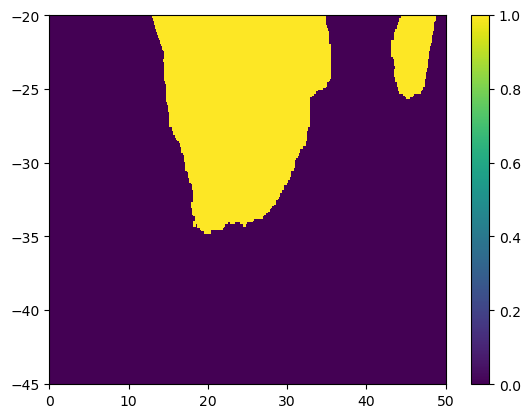

In [6]:
import matplotlib.pylab as plt
plt.pcolormesh(State.lon, State.lat,State.mask)
plt.colorbar()

Instantiate the dynamical model selected by the configuration. 

Reading the boundary condition files might take few minutes...


super: MOD_QG1L
name_class: Qgm
formulation: sf
name_var: {'SSH': 'sla', 'SST': 'sst'}
name_params: None
name_init_var: {}
dir_model: None
var_to_save: None
save_diagnosed_variables: True
save_params: False
upwind: 3
advect_pv: True
advect_tracer: True
dtmodel: 1200
cfl: 0.3
time_scheme: rk2
c0: 2.7
filec_aux: ../../aux/aux_first_baroclinic_speed.nc
name_var_c: {'lon': 'lon', 'lat': 'lat', 'var': 'c1'}
cmin: 2.0
cmax: None
file_bathy_aux: None
name_var_bathy: {'lon': '', 'lat': '', 'var': ''}
bathy_ratio_max: None
solver: spectral
init_from_bc: True
dist_sponge_bc: None
Kdiffus: 150
Kdiffus_trac: None
bc_trac: OBC
forcing_tracer_from_bc: False
sponge_coef: 0.0
constant_c: True
constant_f: True
f0: None
tile_size: 32
tile_overlap: 16
path_mdt: /data1/data/obs/level4/MDT/mdt_hybrid_cnes_cls22_cmems2020_global.nc
name_var_mdt: {'lon': 'longitude', 'lat': 'latitude', 'var': 'mdt'}
bc_file: None
bc_files: {'SSH': {'file': '/data1/data/obs/level4/DUACS_NRT/nrt_global_allsat_phy_l4_202506*.nc

/home/flo/VarDyn/mapping/src/mod.py:104: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  _ds = xr.open_mfdataset(config_bc.file)


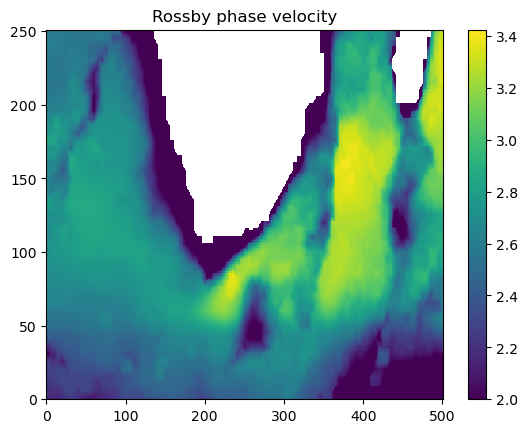

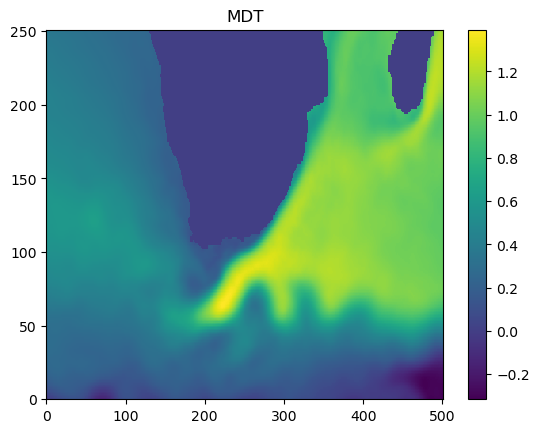

CFL condition for c= 2.6387447071759964
Model time-step 600
  - f₀ (s⁻¹):             -7.7736e-05
  - c  (m/s):              2.6387
  - Rd = c/|f₀| (km):   33.9


In [7]:
from src import mod as mod
Model = mod.Model(config,State)

Open, filter, and preprocess the observation datasets defined in the configuration.


In [8]:
from src import obs as obs
dict_obs = obs.Obs(config,State)

Observation information will be saved in dict_obs_SST_MW_AL_C2N_H2B_S3A_S3B_S6A_SWON_20250601_20250701_0_50_-45_-20_21600.txt
Reading dict_obs_SST_MW_AL_C2N_H2B_S3A_S3B_S6A_SWON_20250601_20250701_0_50_-45_-20_21600.txt from previous run


Build the observation operators that interpolate model variables to the observation locations or grids.


In [9]:
from src import obsop as obsop
Obsop = obsop.Obsop(config,State,dict_obs,Model)

OBSOP_SSH: super: OBSOP_INTERP_L3
name_obs: None
name_var: SSH
write_op: True
path_save: ./H
compute_op: True
Npix: 4
mask_borders: False

OBSOP_SST: super: OBSOP_INTERP_L4
name_obs: None
name_var: SST
write_op: True
path_save: ./H
compute_op: True
mask_borders: False
interp_method: linear
gradients: False


super: OBSOP_INTERP_L3
name_obs: None
name_var: SSH
write_op: True
path_save: ./H
compute_op: True
Npix: 4
mask_borders: False

super: OBSOP_INTERP_L4
name_obs: None
name_var: SST
write_op: True
path_save: ./H
compute_op: True
mask_borders: False
interp_method: linear
gradients: False



Construct the reduced basis used as the 4DVar control-vector representation.


In [10]:
from src import basis as basis
Basis = basis.Basis(config,State)

super: BASIS_GAUSS3D
name_mod_var: sla
c_grid_var: None
compute_velocities: False
name_mod_u: u
name_mod_v: v
flux: True
facns: 3.0
facnlt: 3.0
sigma_D: 970
sigma_T: 25
sigma_Q: 0.03
fcor: 0.5
normalize_fact: True
time_spinup: None
flag_variable_Q: False
path_sad: None
name_var_sad: {'lon': '', 'lat': '', 'var': ''}
path_background: None
var_background: None

super: BASIS_BMaux
name_mod_var: sla
c_grid_var: None
compute_velocities: False
name_mod_u: u
name_mod_v: v
flux: False
facns: 1.0
facnlt: 2.0
npsp: 3.5
facpsp: 1.5
file_aux: ../../aux/aux_reduced_basis_BM.nc
lmin: 80
lmax: 1000.0
factdec: 7.5
tdecmin: 2.0
tdecmax: 40.0
facQ: 1
facQ_aux_path: None
l_largescale: 500
facQ_largescale: 1
file_depth: None
name_var_depth: {'lon': '', 'lat': '', 'var': ''}
depth1: 0.0
depth2: 30.0
path_background: None
var_background: None
norm_time: True
file_facQaux: None
name_var_facQaux: {'wavenumber': '', 'lon': '', 'lat': '', 'var': ''}

super: BASIS_GAUSS3D
name_mod_var: sst
c_grid_var: None
compu

Run the 4DVar inversion with the configured model, observations, operators, and basis.


super: INV_4DVAR
compute_test: False
freq_it_plot: 10
print_time: False
JAX_mem_fraction: None
path_init_4Dvar: None
restart_4Dvar: False
ftol: 5e-05
gtol: None
convergence_nit: 10
maxiter: 50
gradient_max_norm: 1000000000000.0
max_retries: 10
opt_method: L-BFGS-B
save_minimization: True
path_save_control_vectors: ./controls/VarDyn-QG
timestep_checkpoint: 6:00:00
sigma_R: None
sigma_B: None
prec: True
path_background: None
anomaly_from_bc: False

process observation operators
Processing observations at date 2025-06-01 00:00:00 for variable SST...
Processing observations at date 2025-06-02 00:00:00 for variable SST...
Processing observations at date 2025-06-03 00:00:00 for variable SST...
Processing observations at date 2025-06-04 00:00:00 for variable SST...
Processing observations at date 2025-06-05 00:00:00 for variable SST...
Processing observations at date 2025-06-06 00:00:00 for variable SST...
Processing observations at date 2025-06-07 00:00:00 for variable SST...
Processing obse

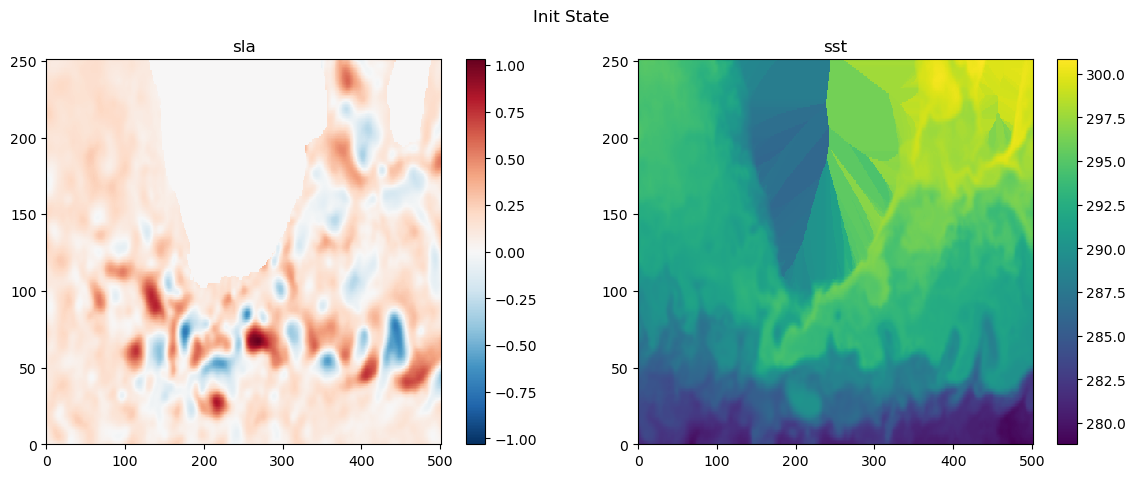

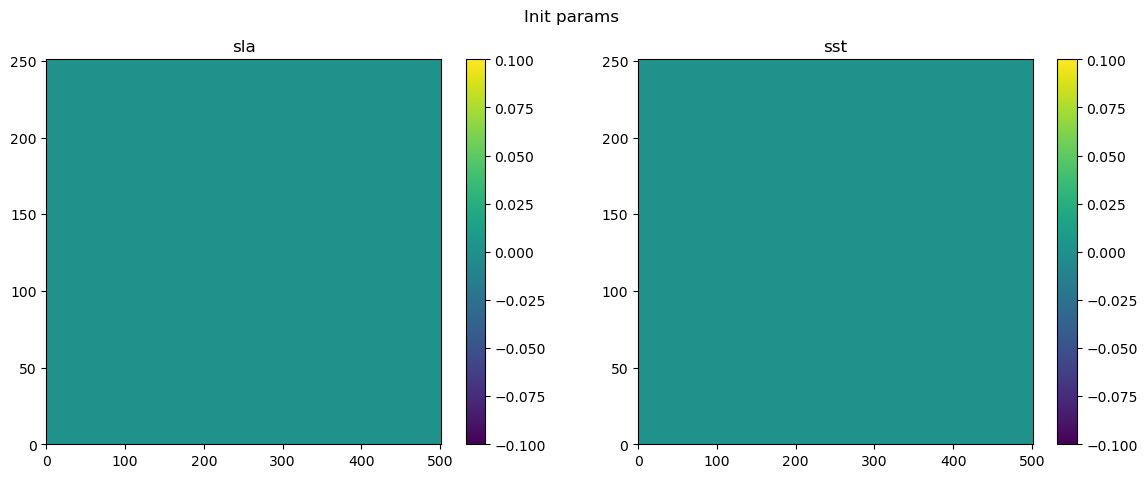

lambda=9.7E+02 nlocs=2.3E+02 tdec=2.5E+01 ntime=8.0E+00 Q=1.0E-02
reduced order: 15215871 --> 1832
 reduced factor: 8305
Setting Basis BMaux...
Computing Q
lambda=1.4E+03 nlocs=6.0E+00 tdec=2.0E+00 Q=1.0E-10
lambda=9.7E+02 nlocs=1.1E+01 tdec=1.3E+01 Q=1.4E-03
lambda=6.8E+02 nlocs=1.3E+01 tdec=9.7E+00 Q=2.3E-03
lambda=4.8E+02 nlocs=2.5E+01 tdec=9.0E+00 Q=3.5E-03
lambda=3.3E+02 nlocs=5.0E+01 tdec=8.5E+00 Q=3.6E-03
lambda=2.3E+02 nlocs=8.6E+01 tdec=6.5E+00 Q=2.7E-03
lambda=1.6E+02 nlocs=1.5E+02 tdec=3.7E+00 Q=1.6E-03
lambda=1.1E+02 nlocs=3.0E+02 tdec=2.5E+00 Q=1.2E-03
lambda=8.0E+01 nlocs=5.6E+02 tdec=2.2E+00 Q=7.6E-04
Computing Spatial components
Computing Time components
reduced order: 15215871 --> 619380
 reduced factor: 24
lambda=1.0E+03 nlocs=2.1E+02 tdec=3.0E+00 ntime=3.4E+01 Q=1.7E-01
reduced order: 15215871 --> 7072
 reduced factor: 2151
lambda=9.7E+02 nlocs=2.3E+02 tdec=2.5E+01 ntime=8.0E+00 Q=1.7E-01
reduced order: 15215871 --> 1832
 reduced factor: 8305
Setting Basis BMaux...
C

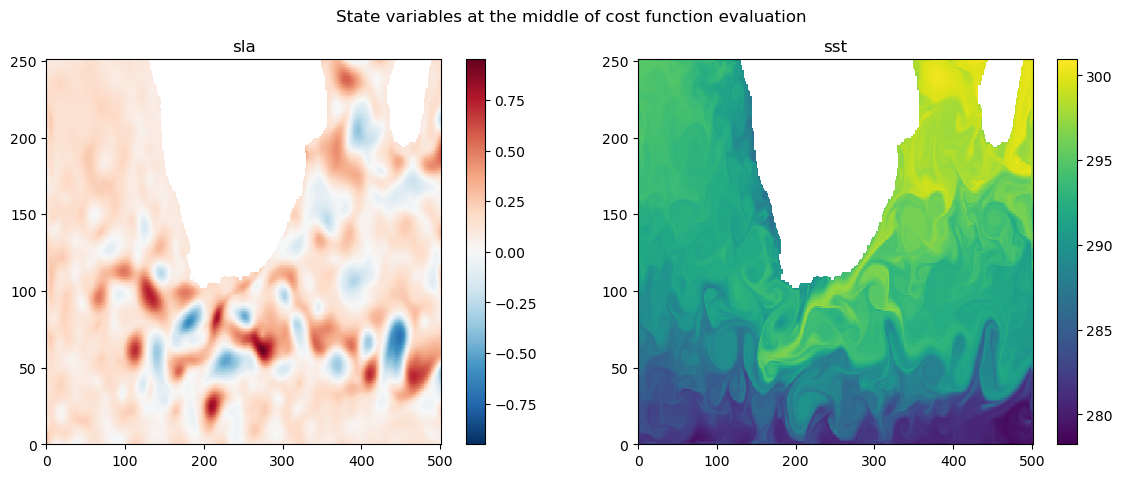

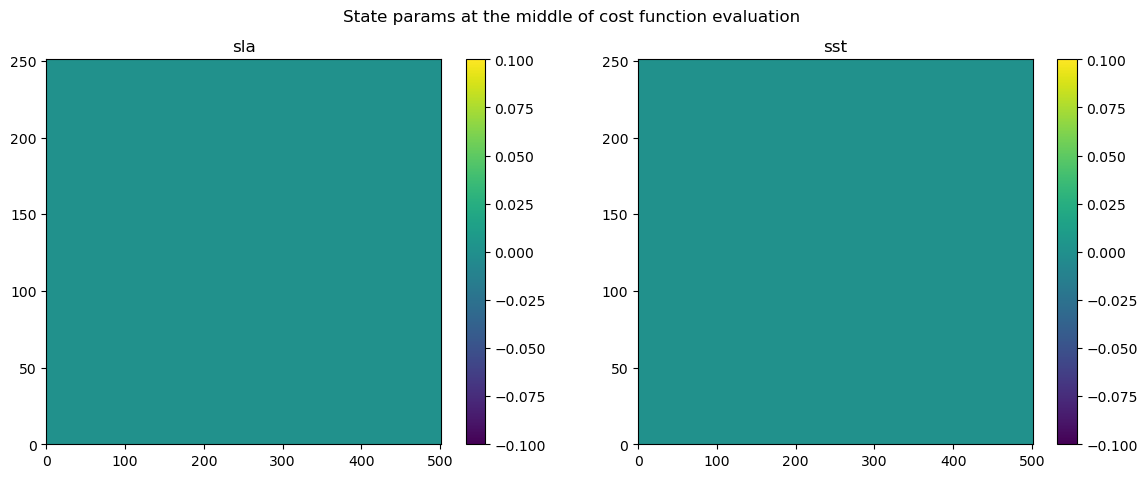

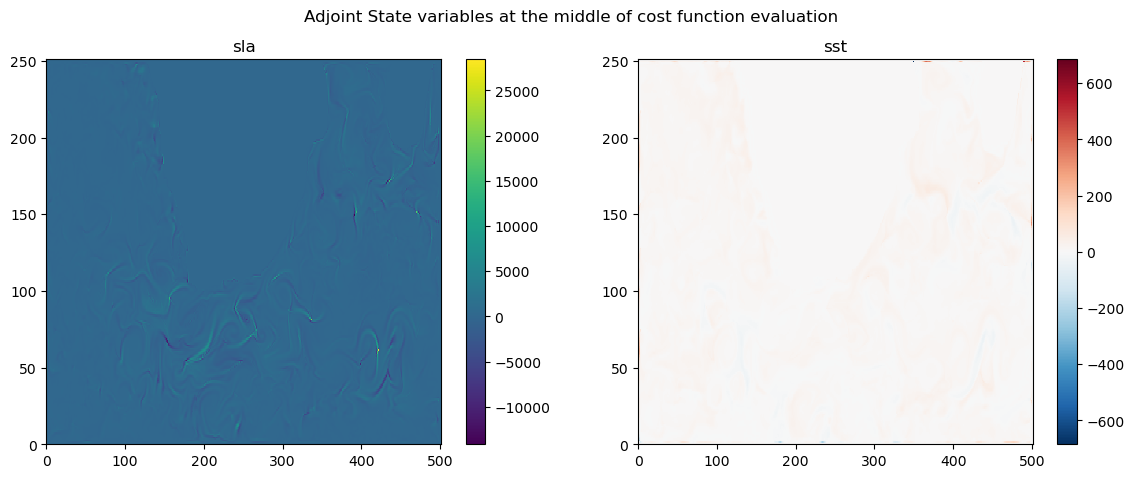

* iteration 1 computed in 4.46E+00 second:, x=0.00E+00, J=3.56E+06, G=3.00E+01, ftol=9.10E-13, gtol=1.76E-08
* iteration 2 computed in 4.57E+00 second:, x=-8.62E-08, J=3.25E+06, G=2.47E+01, ftol=8.74E-02, gtol=1.77E-01
* iteration 3 computed in 4.54E+00 second:, x=2.59E-07, J=2.81E+06, G=1.75E+01, ftol=1.35E-01, gtol=2.93E-01
* iteration 4 computed in 4.43E+00 second:, x=1.25E-06, J=2.61E+06, G=1.78E+01, ftol=7.20E-02, gtol=1.89E-02
* iteration 5 computed in 4.55E+00 second:, x=7.98E-06, J=2.07E+06, G=1.71E+01, ftol=2.07E-01, gtol=3.85E-02
* iteration 6 computed in 4.56E+00 second:, x=2.58E-05, J=1.55E+06, G=1.44E+01, ftol=2.53E-01, gtol=1.59E-01
* iteration 7 computed in 4.66E+00 second:, x=2.99E-05, J=1.56E+06, G=1.61E+01, ftol=1.04E-02, gtol=1.04E-01
* iteration 8 computed in 4.42E+00 second:, x=2.78E-05, J=1.37E+06, G=1.13E+01, ftol=1.26E-01, gtol=2.96E-01
* iteration 9 computed in 4.55E+00 second:, x=3.10E-05, J=1.24E+06, G=8.94E+00, ftol=9.10E-02, gtol=2.10E-01


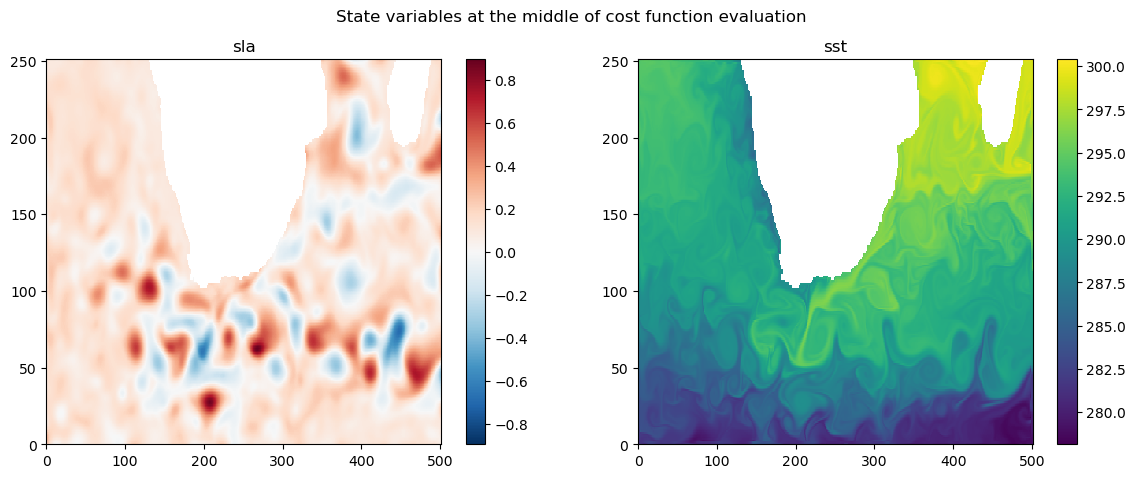

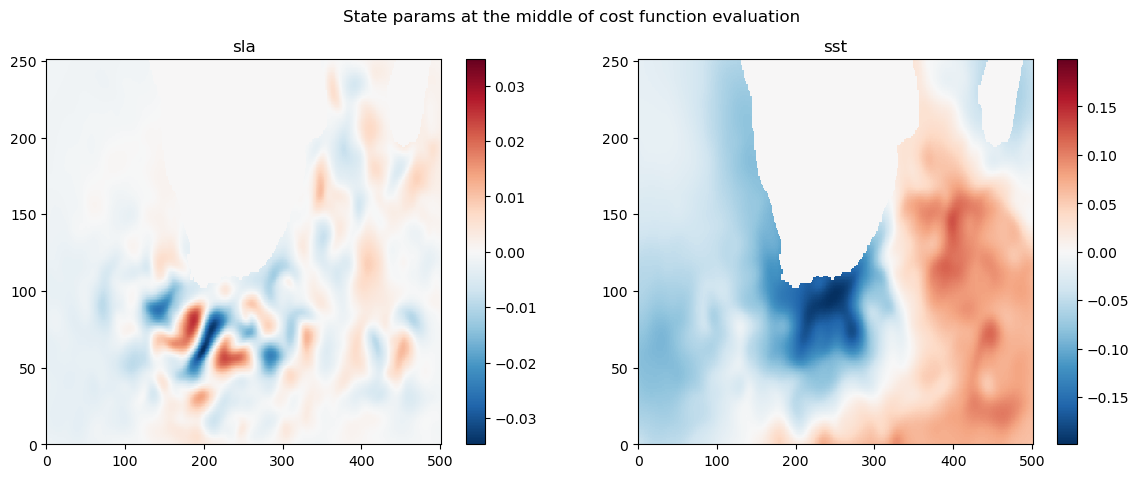

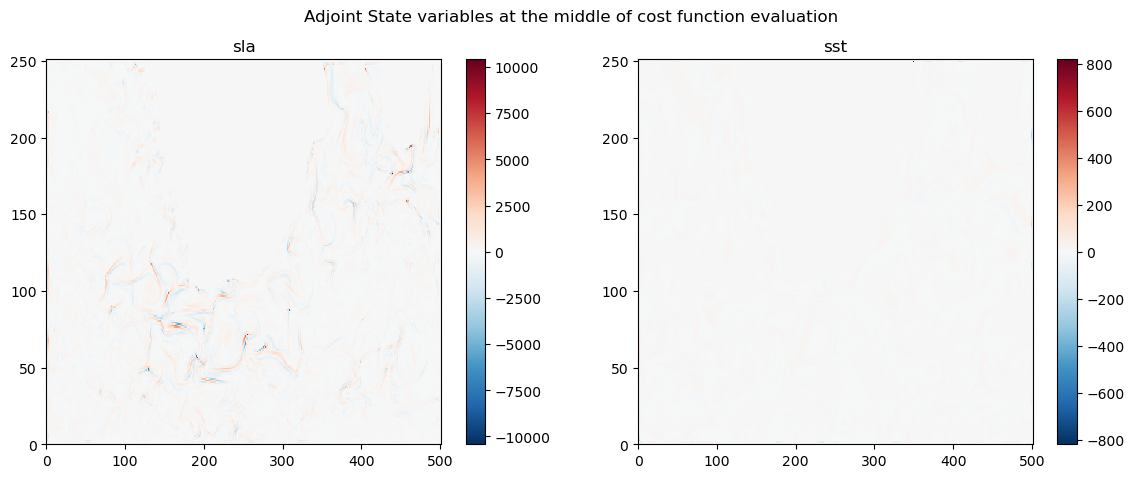

* iteration 10 computed in 6.42E+00 second:, x=3.27E-05, J=1.16E+06, G=8.86E+00, ftol=6.37E-02, gtol=8.98E-03
* iteration 11 computed in 4.66E+00 second:, x=3.45E-05, J=1.09E+06, G=9.51E+00, ftol=6.17E-02, gtol=6.80E-02
* iteration 12 computed in 4.64E+00 second:, x=3.64E-05, J=1.00E+06, G=8.22E+00, ftol=7.94E-02, gtol=1.36E-01
* iteration 13 computed in 4.58E+00 second:, x=3.86E-05, J=9.32E+05, G=7.17E+00, ftol=7.23E-02, gtol=1.28E-01
* iteration 14 computed in 4.53E+00 second:, x=3.83E-05, J=8.88E+05, G=6.89E+00, ftol=4.72E-02, gtol=3.84E-02
* iteration 15 computed in 4.62E+00 second:, x=3.67E-05, J=8.32E+05, G=6.47E+00, ftol=6.35E-02, gtol=6.08E-02
* iteration 16 computed in 4.58E+00 second:, x=3.25E-05, J=8.07E+05, G=8.42E+00, ftol=2.98E-02, gtol=2.31E-01
* iteration 17 computed in 4.52E+00 second:, x=3.00E-05, J=7.41E+05, G=5.38E+00, ftol=8.22E-02, gtol=3.61E-01
* iteration 18 computed in 4.58E+00 second:, x=2.80E-05, J=7.22E+05, G=4.81E+00, ftol=2.49E-02, gtol=1.06E-01
* iteratio

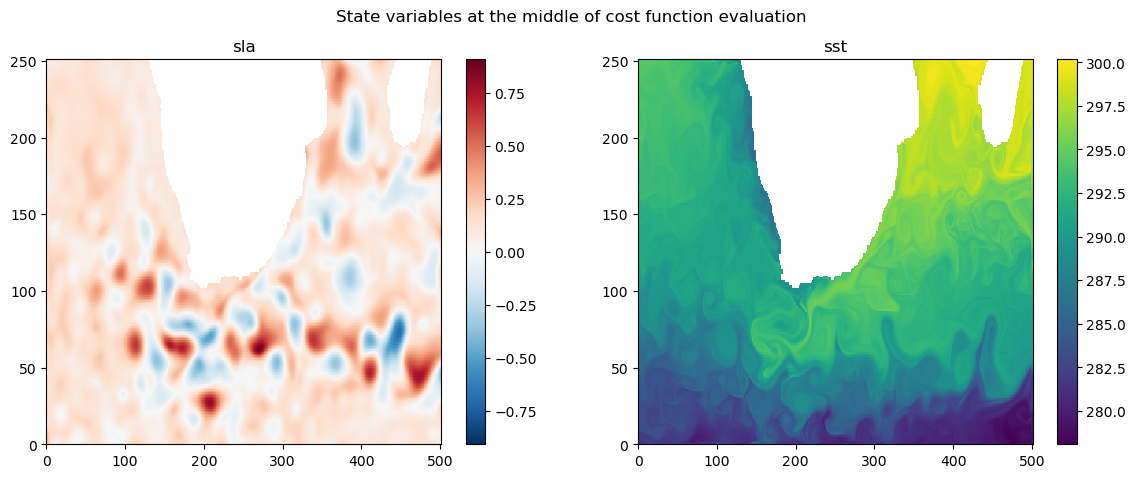

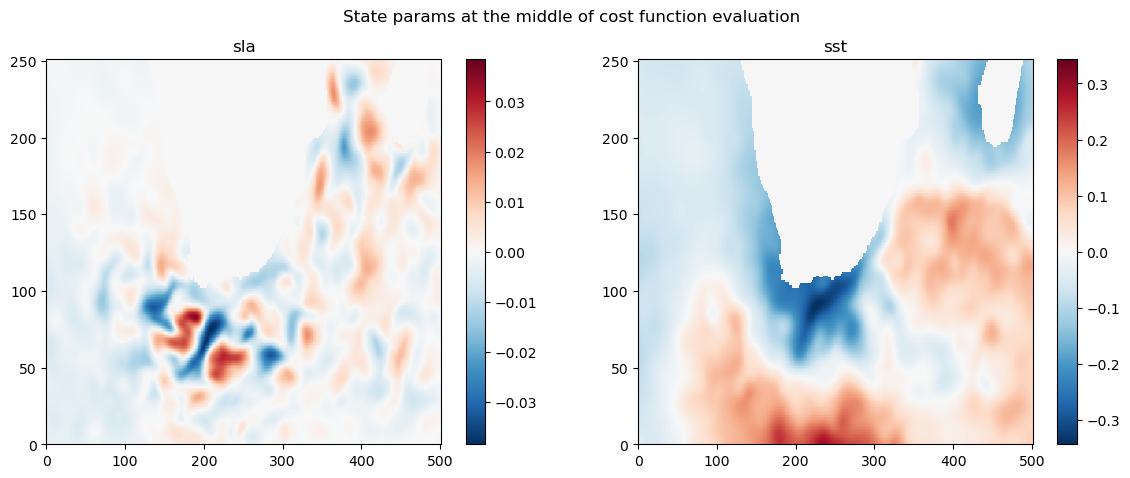

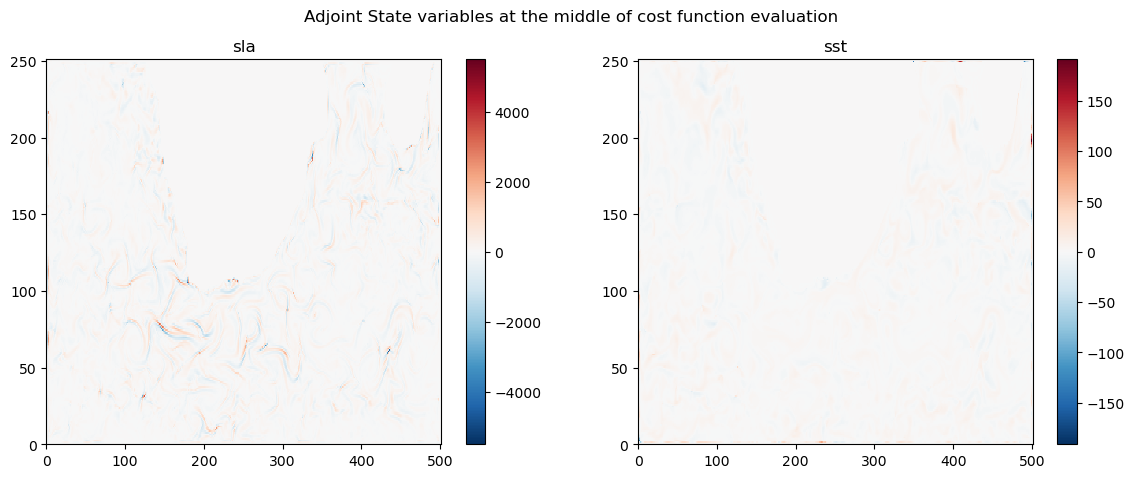

* iteration 20 computed in 6.47E+00 second:, x=1.77E-05, J=6.59E+05, G=4.98E+00, ftol=5.69E-02, gtol=1.97E-03
* iteration 21 computed in 4.59E+00 second:, x=7.80E-06, J=6.96E+05, G=8.59E+00, ftol=5.36E-02, gtol=4.20E-01
* iteration 22 computed in 4.50E+00 second:, x=1.42E-05, J=6.43E+05, G=5.47E+00, ftol=7.60E-02, gtol=3.64E-01
* iteration 23 computed in 4.53E+00 second:, x=1.01E-05, J=6.19E+05, G=4.28E+00, ftol=3.82E-02, gtol=2.17E-01
* iteration 24 computed in 4.60E+00 second:, x=7.65E-06, J=6.04E+05, G=4.13E+00, ftol=2.35E-02, gtol=3.39E-02
* iteration 25 computed in 4.62E+00 second:, x=4.91E-06, J=5.91E+05, G=4.68E+00, ftol=2.11E-02, gtol=1.17E-01
* iteration 26 computed in 4.57E+00 second:, x=2.53E-06, J=5.77E+05, G=4.38E+00, ftol=2.51E-02, gtol=6.44E-02
* iteration 27 computed in 4.66E+00 second:, x=-9.85E-07, J=5.60E+05, G=3.80E+00, ftol=2.91E-02, gtol=1.33E-01
* iteration 28 computed in 4.60E+00 second:, x=-5.26E-06, J=5.45E+05, G=3.66E+00, ftol=2.61E-02, gtol=3.49E-02
* iterat

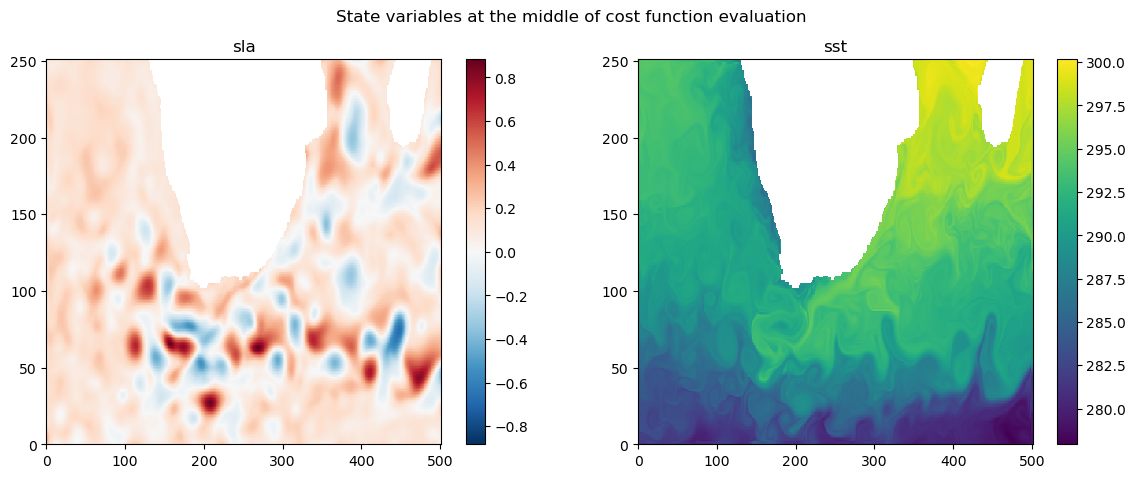

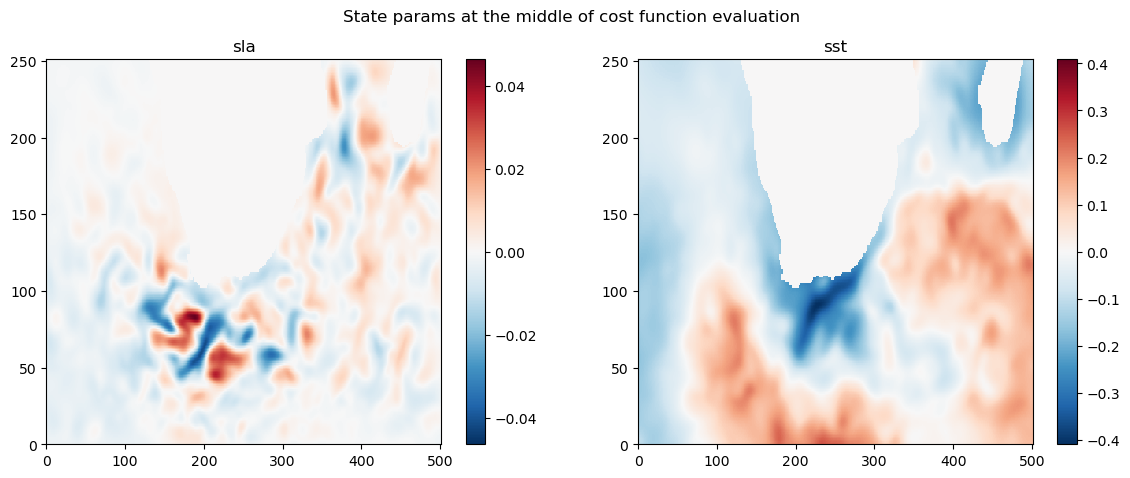

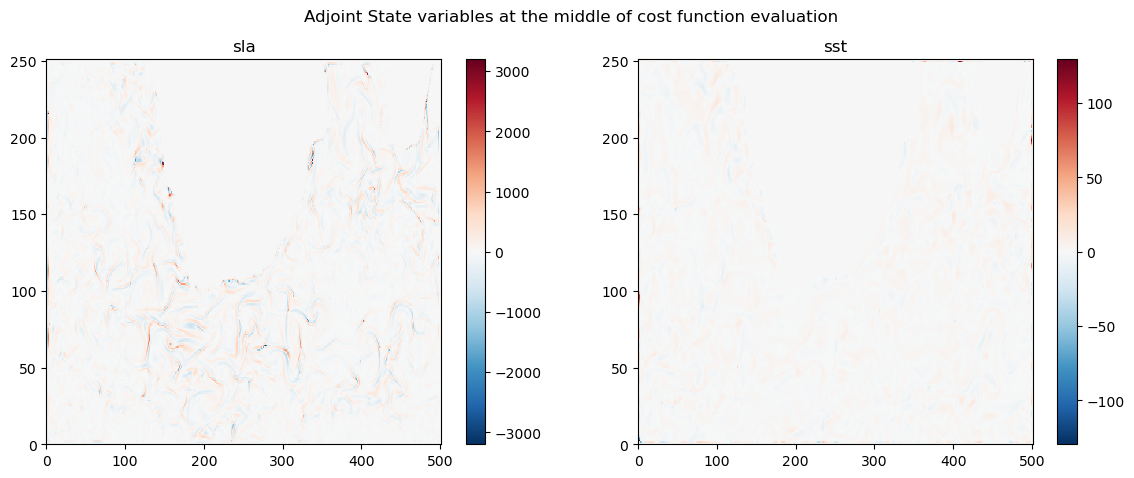

* iteration 30 computed in 6.33E+00 second:, x=-1.40E-05, J=5.18E+05, G=3.60E+00, ftol=2.27E-02, gtol=4.23E-02
* iteration 31 computed in 4.59E+00 second:, x=-1.71E-05, J=5.06E+05, G=3.61E+00, ftol=2.30E-02, gtol=1.30E-03
* iteration 32 computed in 4.57E+00 second:, x=-1.75E-05, J=4.97E+05, G=3.16E+00, ftol=1.67E-02, gtol=1.24E-01
* iteration 33 computed in 4.59E+00 second:, x=-1.78E-05, J=4.88E+05, G=3.11E+00, ftol=1.94E-02, gtol=1.52E-02
* iteration 34 computed in 4.55E+00 second:, x=-2.04E-05, J=4.78E+05, G=3.55E+00, ftol=1.95E-02, gtol=1.23E-01
* iteration 35 computed in 4.55E+00 second:, x=-2.37E-05, J=4.69E+05, G=3.03E+00, ftol=1.92E-02, gtol=1.46E-01
* iteration 36 computed in 4.58E+00 second:, x=-2.84E-05, J=4.60E+05, G=2.86E+00, ftol=1.90E-02, gtol=5.76E-02
* iteration 37 computed in 4.59E+00 second:, x=-3.53E-05, J=4.53E+05, G=3.29E+00, ftol=1.51E-02, gtol=1.31E-01
* iteration 38 computed in 4.49E+00 second:, x=-3.99E-05, J=4.46E+05, G=2.90E+00, ftol=1.63E-02, gtol=1.17E-01
*

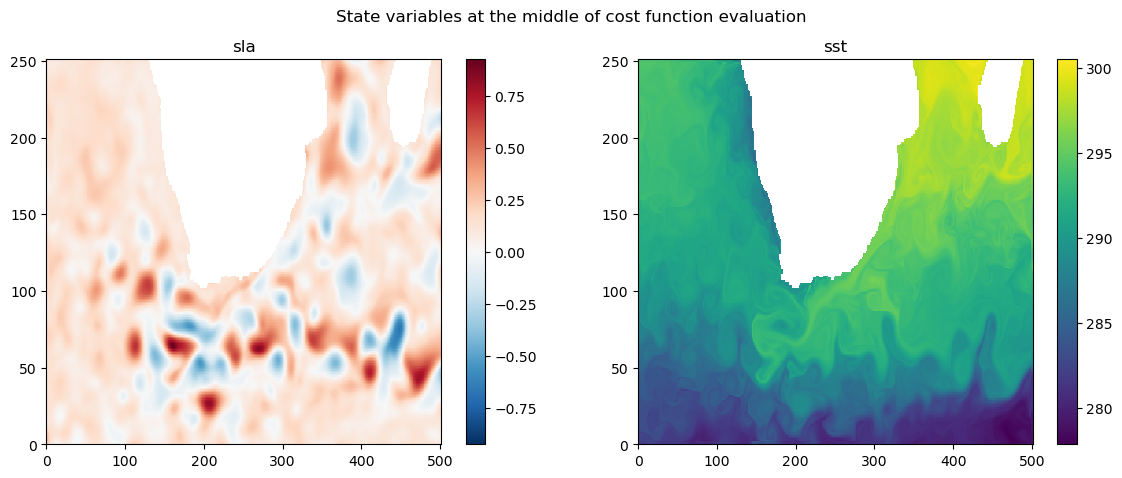

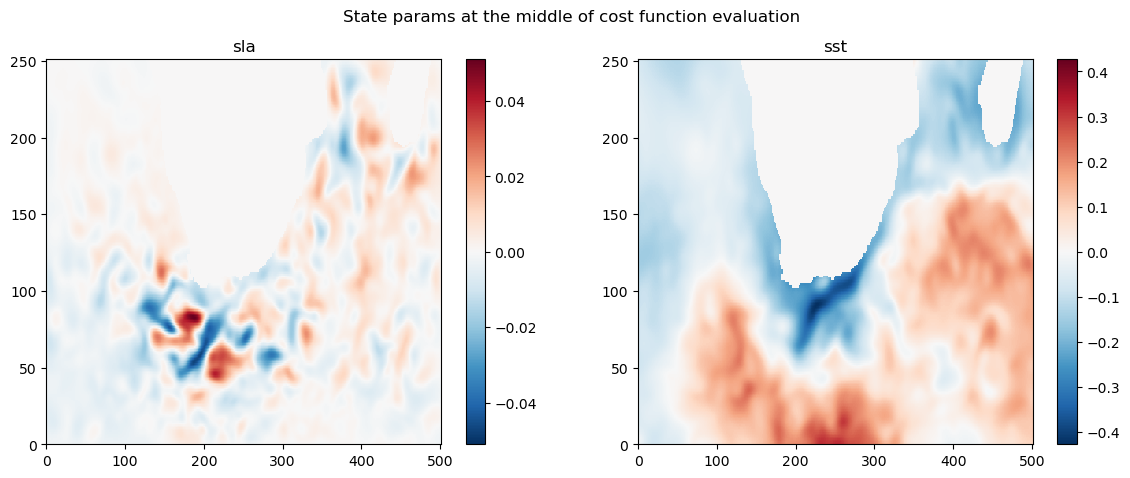

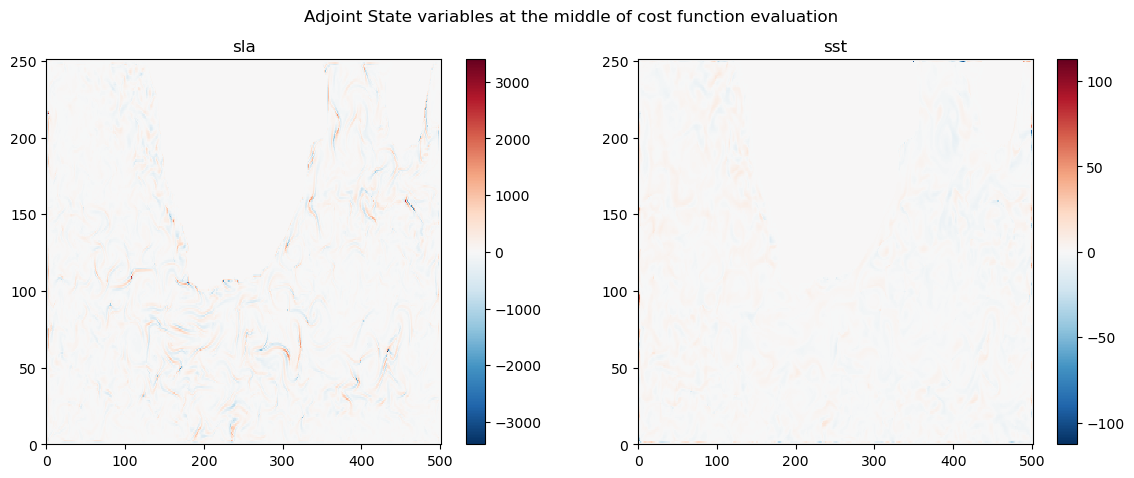

* iteration 40 computed in 6.36E+00 second:, x=-4.78E-05, J=4.34E+05, G=3.19E+00, ftol=1.34E-02, gtol=1.43E-01
* iteration 41 computed in 4.57E+00 second:, x=-5.05E-05, J=4.28E+05, G=2.67E+00, ftol=1.31E-02, gtol=1.63E-01
* iteration 42 computed in 4.52E+00 second:, x=-5.22E-05, J=4.24E+05, G=2.48E+00, ftol=9.15E-03, gtol=7.16E-02
* iteration 43 computed in 4.53E+00 second:, x=-5.95E-05, J=4.16E+05, G=2.42E+00, ftol=1.88E-02, gtol=2.41E-02
* iteration 44 computed in 4.45E+00 second:, x=-6.72E-05, J=4.13E+05, G=3.10E+00, ftol=9.29E-03, gtol=2.20E-01
* iteration 45 computed in 4.50E+00 second:, x=-7.27E-05, J=4.06E+05, G=2.57E+00, ftol=1.52E-02, gtol=1.72E-01
* iteration 46 computed in 4.54E+00 second:, x=-8.25E-05, J=3.99E+05, G=2.26E+00, ftol=1.86E-02, gtol=1.19E-01
* iteration 47 computed in 4.60E+00 second:, x=-8.85E-05, J=3.95E+05, G=2.33E+00, ftol=1.06E-02, gtol=2.67E-02
* iteration 48 computed in 4.55E+00 second:, x=-1.00E-04, J=3.90E+05, G=3.02E+00, ftol=1.22E-02, gtol=2.29E-01
*

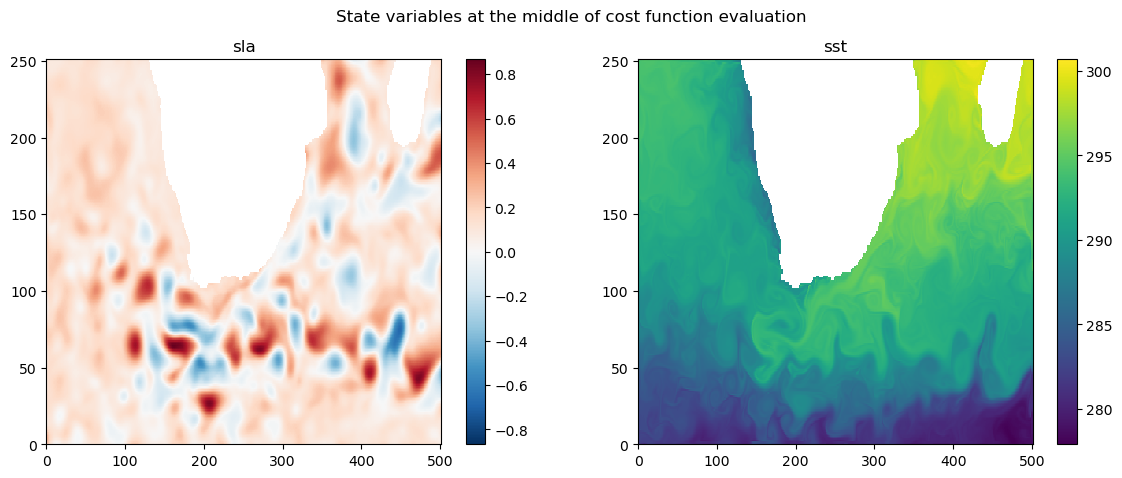

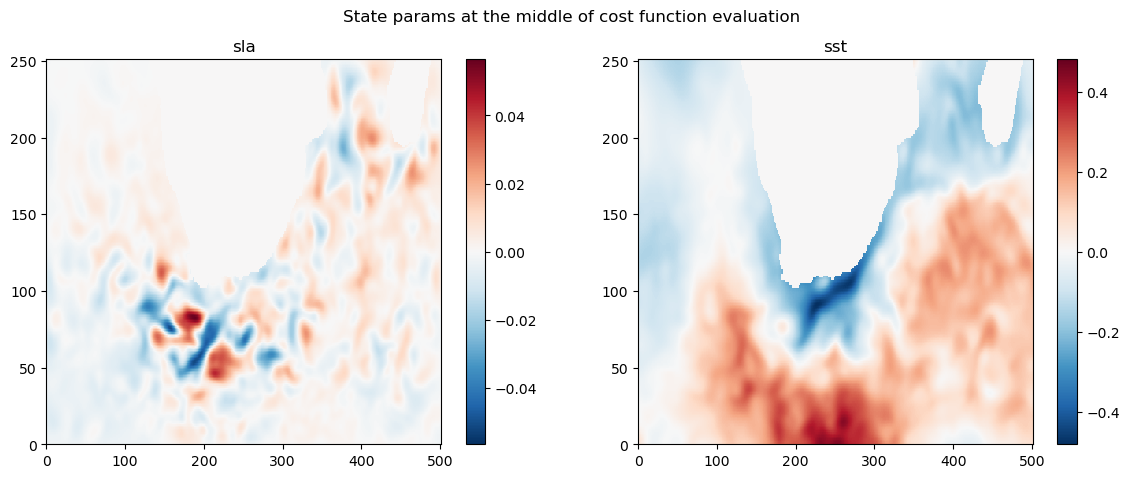

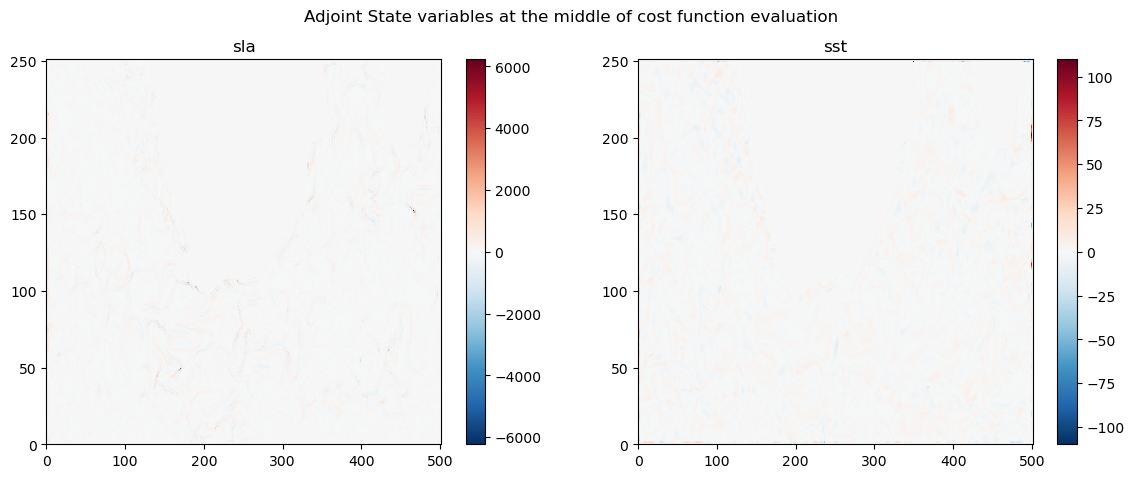

* iteration 50 computed in 6.22E+00 second:, x=-1.06E-04, J=3.80E+05, G=2.11E+00, ftol=8.63E-03, gtol=1.06E-01
* iteration 51 computed in 4.51E+00 second:, x=-1.08E-04, J=3.75E+05, G=2.23E+00, ftol=1.11E-02, gtol=5.47E-02
* iteration 52 computed in 4.61E+00 second:, x=-1.18E-04, J=3.73E+05, G=2.86E+00, ftol=6.32E-03, gtol=2.20E-01
* iteration 53 computed in 4.72E+00 second:, x=-1.20E-04, J=3.69E+05, G=2.18E+00, ftol=1.05E-02, gtol=2.37E-01

Is the minimization successful? False

Final cost function value: 369152.4778691157

Number of iterations: 50

*** Saving trajectory ***



In [ ]:
from src import inv as inv
inv.Inv(config,State,Model,dict_obs=dict_obs,Obsop=Obsop,Basis=Basis,gpu_device=NUM_GPU)  